## imports

In [18]:
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("Imports done ")

Imports done 


## load data

In [20]:
from google.colab import files
uploaded = files.upload()
df = pd.read_csv('training_data.csv')
print(f"Shape: {df.shape}")
df.head()

Saving training_data.csv to training_data (1).csv
Shape: (4750, 10)


,click_count,avg_click_interval,click_interval_variance,click_interval_entropy,mouse_velocity_variance,max_element_click_rate,scroll_events,keystroke_count,persona,label
0,200,22.609732,6.132684,0.014982,0.000000,39.292982,0.0,0.0,http_flooder,bot
1,8,1524.943564,269875.235918,2.304230,0.356148,1.201258,11.0,5.0,casual_browser,human
2,4,1540.784354,254741.917130,2.607192,0.786881,1.449804,11.0,3.0,casual_browser,human
3,15,477.774439,114469.093339,2.897984,0.321347,1.323701,2.0,56.0,power_user,human
4,19,428.310760,117565.233111,2.981485,1.028971,2.472009,3.0,58.0,power_user,human


## v1 model(baseline)



In [21]:
FEATURES_V1 = [
    'click_count', 'avg_click_interval', 'click_interval_variance',
    'click_interval_entropy', 'mouse_velocity_variance',
    'max_element_click_rate', 'scroll_events', 'keystroke_count'
]

human_df = df[df['label'] == 'human'][FEATURES_V1]

scaler_v1 = StandardScaler()
X_train_v1 = scaler_v1.fit_transform(human_df)

model_v1 = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model_v1.fit(X_train_v1)

X_test_v1 = scaler_v1.transform(df[FEATURES_V1])
preds_v1 = model_v1.predict(X_test_v1)
df['predicted_v1'] = ['bot' if p == -1 else 'human' for p in preds_v1]

print("V1 Results:")
print(classification_report(df['label'], df['predicted_v1']))

V1 Results:
              precision    recall  f1-score   support

         bot       0.96      1.00      0.98      1000
       human       1.00      0.99      0.99      3750

    accuracy                           0.99      4750
   macro avg       0.98      0.99      0.99      4750
weighted avg       0.99      0.99      0.99      4750



#feature engineering

In [25]:
# Log transform — large value features ko compress karo
df['log_variance'] = np.log1p(df['click_interval_variance'])
df['log_click_count'] = np.log1p(df['click_count'])
df['log_keystroke'] = np.log1p(df['keystroke_count'])

# Interaction term — variance aur entropy milake zyada powerful signal
df['variance_x_entropy'] = df['click_interval_variance'] * df['click_interval_entropy']

print("Feature engineering done ")
df[['log_variance', 'log_click_count', 'log_keystroke', 'variance_x_entropy']].head()

Feature engineering done 


,log_variance,log_click_count,log_keystroke,variance_x_entropy
0,1.964688,5.303305,0.000000,0.091880
1,12.505719,2.197225,1.791759,621854.588494
2,12.448010,1.609438,1.386294,664161.139639
3,11.648069,2.772589,4.043051,331729.638124
4,11.674757,2.995732,4.077537,350518.920515


## v2 model

In [23]:
FEATURES_V2 = [
    'log_variance', 'log_click_count', 'log_keystroke',
    'avg_click_interval', 'click_interval_entropy',
    'mouse_velocity_variance', 'max_element_click_rate',
    'scroll_events', 'variance_x_entropy'
]

human_v2 = df[df['label'] == 'human'][FEATURES_V2]

scaler_v2 = StandardScaler()
X_train_v2 = scaler_v2.fit_transform(human_v2)

model_v2 = IsolationForest(n_estimators=100, contamination=0.01, random_state=42)
model_v2.fit(X_train_v2)

X_test_v2 = scaler_v2.transform(df[FEATURES_V2])
preds_v2 = model_v2.predict(X_test_v2)
df['predicted_v2'] = ['bot' if p == -1 else 'human' for p in preds_v2]

print("V2 Results:")
print(classification_report(df['label'], df['predicted_v2']))

V2 Results:
              precision    recall  f1-score   support

         bot       0.96      1.00      0.98      1000
       human       1.00      0.99      0.99      3750

    accuracy                           0.99      4750
   macro avg       0.98      0.99      0.99      4750
weighted avg       0.99      0.99      0.99      4750



## v1 vs v2 comparison

                     Model  Accuracy    Bot F1  Bot Recall
0            V1 (baseline)     0.992  0.981354    0.981354
1  V2 (feature engineered)     0.992  0.981354    0.981354


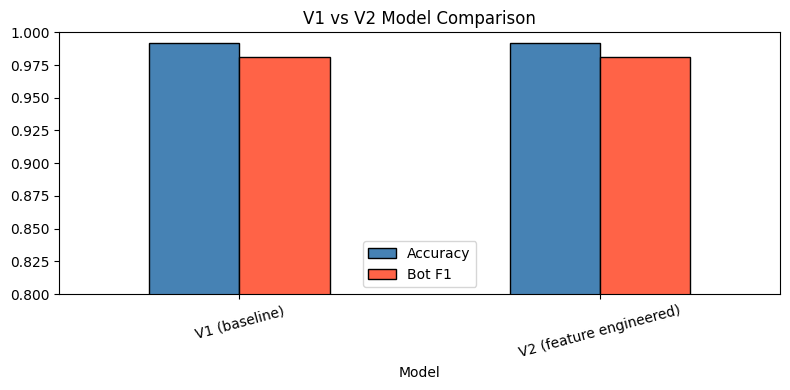

In [24]:
from sklearn.metrics import accuracy_score, f1_score

comparison = pd.DataFrame({
    'Model': ['V1 (baseline)', 'V2 (feature engineered)'],
    'Accuracy': [
        accuracy_score(df['label'], df['predicted_v1']),
        accuracy_score(df['label'], df['predicted_v2'])
    ],
    'Bot F1': [
        f1_score(df['label'], df['predicted_v1'], pos_label='bot'),
        f1_score(df['label'], df['predicted_v2'], pos_label='bot')
    ],
    'Bot Recall': [
        f1_score(df['label'], df['predicted_v1'], pos_label='bot', average='binary'),
        f1_score(df['label'], df['predicted_v2'], pos_label='bot', average='binary')
    ]
})

print(comparison)

# Plot
comparison.set_index('Model')[['Accuracy', 'Bot F1']].plot(
    kind='bar', figsize=(8, 4), color=['steelblue', 'tomato'], edgecolor='black')
plt.title('V1 vs V2 Model Comparison')
plt.xticks(rotation=15)
plt.ylim(0.8, 1.0)
plt.tight_layout()
plt.show()